In [1]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

Image loaded successfully with dimensions: (365, 547, 3)


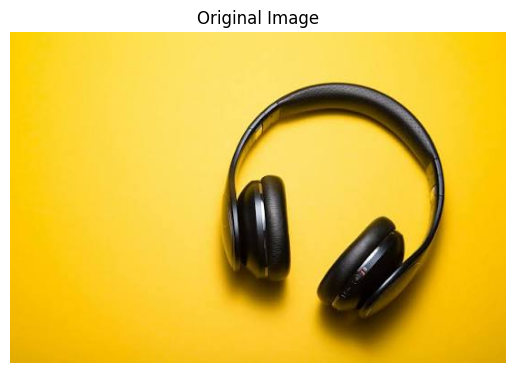

In [7]:
image_path = '/content/product.jpg'
original_image = cv2.imread(image_path)

# Check if image was loaded successfully
if original_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    print(f"Image loaded successfully with dimensions: {original_image.shape}")
    # Convert BGR to RGB for displaying with matplotlib
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    plt.imshow(original_image_rgb)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

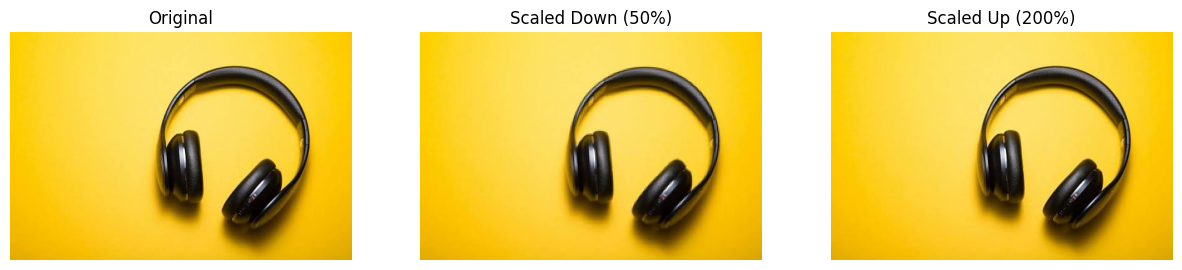

In [8]:
if original_image is not None:
    # Get original dimensions
    height, width = original_image.shape[:2]

    # Scale down to 50%
    scaled_down_image = cv2.resize(original_image, (int(width * 0.5), int(height * 0.5)), interpolation=cv2.INTER_AREA)
    scaled_down_image_rgb = cv2.cvtColor(scaled_down_image, cv2.COLOR_BGR2RGB)

    # Scale up to 200%
    scaled_up_image = cv2.resize(original_image, (int(width * 2), int(height * 2)), interpolation=cv2.INTER_CUBIC)
    scaled_up_image_rgb = cv2.cvtColor(scaled_up_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(original_image_rgb)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(scaled_down_image_rgb)
    plt.title('Scaled Down (50%)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(scaled_up_image_rgb)
    plt.title('Scaled Up (200%)')
    plt.axis('off')
    plt.show()
else:
    print("Cannot perform scaling, original image not loaded.")

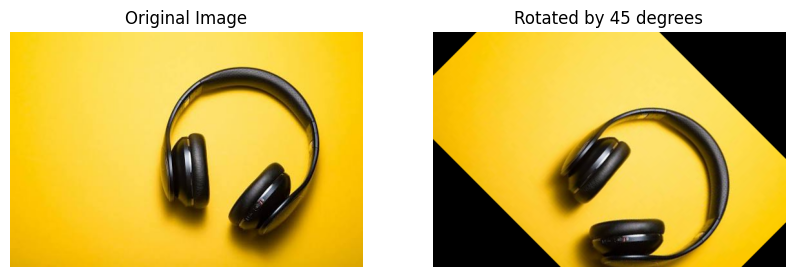

In [9]:
if original_image is not None:
    # Get image dimensions
    (h, w) = original_image.shape[:2]
    center = (w // 2, h // 2)

    # Rotate image by 45 degrees
    M_rotate = cv2.getRotationMatrix2D(center, -45, 1.0) # -45 for clockwise rotation
    rotated_image = cv2.warpAffine(original_image, M_rotate, (w, h))
    rotated_image_rgb = cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(rotated_image_rgb)
    plt.title('Rotated by 45 degrees')
    plt.axis('off')
    plt.show()
else:
    print("Cannot perform rotation, original image not loaded.")

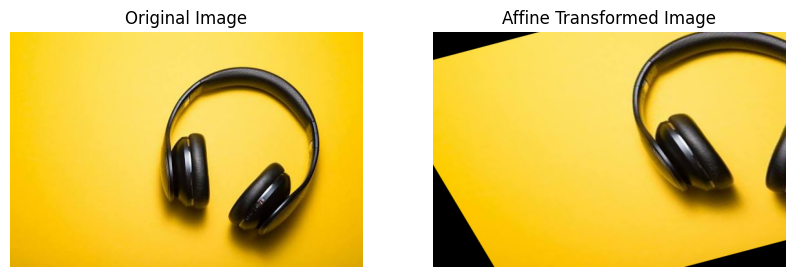

In [10]:
if original_image is not None:
    rows, cols, ch = original_image.shape

    # Define 3 points on the original image
    pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
    # Define their corresponding points on the output image
    pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

    # Get the affine transformation matrix
    M_affine = cv2.getAffineTransform(pts1, pts2)

    # Apply the affine transformation
    affine_transformed_image = cv2.warpAffine(original_image, M_affine, (cols, rows))
    affine_transformed_image_rgb = cv2.cvtColor(affine_transformed_image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(affine_transformed_image_rgb)
    plt.title('Affine Transformed Image')
    plt.axis('off')
    plt.show()
else:
    print("Cannot perform affine transformation, original image not loaded.")

Detected objects and their estimated dimensions (in pixels):
  Object 79: Width = 90 pixels, Height = 91 pixels
  Object 83: Width = 96 pixels, Height = 123 pixels
  Object 87: Width = 10 pixels, Height = 63 pixels
  Object 89: Width = 249 pixels, Height = 254 pixels


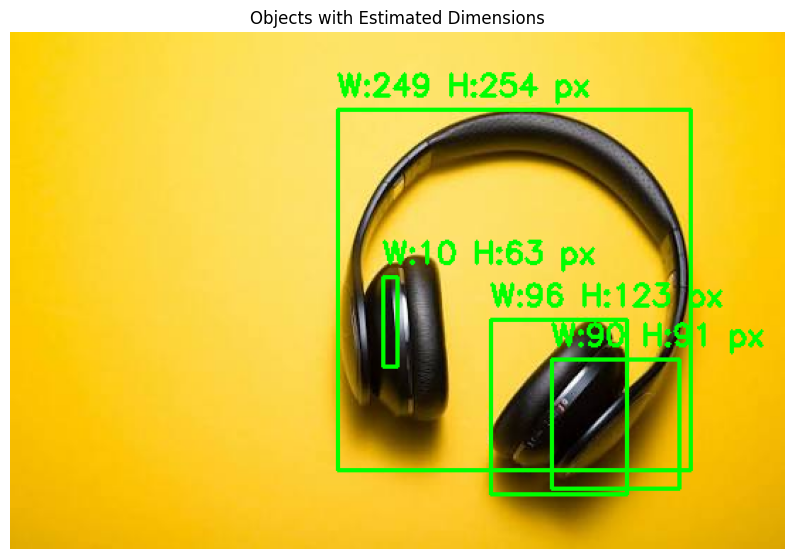

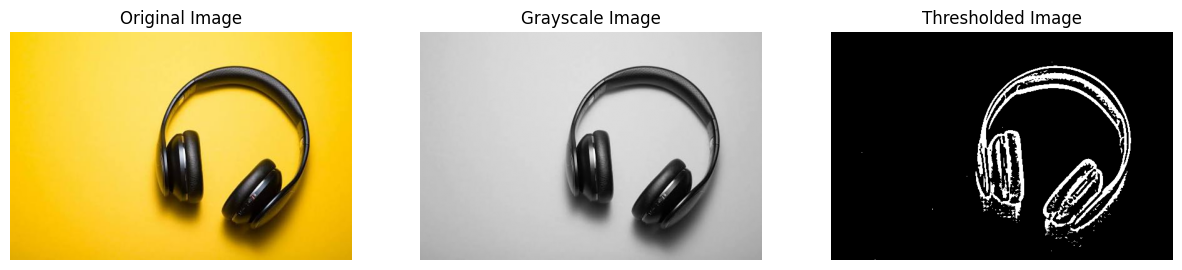

In [11]:
if original_image is not None:
    # Convert to grayscale
    gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise and help with contour detection
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

    # Apply adaptive thresholding to get a binary image
    # Using ADAPTIVE_THRESH_GAUSSIAN_C as it tends to work well for varying lighting
    thresh_image = cv2.adaptiveThreshold(blurred_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY_INV, 11, 2)

    # Find contours
    contours, hierarchy = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a copy of the original image to draw on
    image_with_measurements = original_image.copy()

    print("Detected objects and their estimated dimensions (in pixels):")

    min_contour_area = 100 # Filter out small noise artifacts

    for i, contour in enumerate(contours):
        # Calculate area and filter small contours
        if cv2.contourArea(contour) < min_contour_area:
            continue

        # Get the bounding rectangle for the contour
        x, y, w, h = cv2.boundingRect(contour)

        # Draw the bounding box on the image
        cv2.rectangle(image_with_measurements, (x, y), (x + w, y + h), (0, 255, 0), 2) # Green rectangle

        # Put text with dimensions
        text = f"W:{w} H:{h} px"
        cv2.putText(image_with_measurements, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        print(f"  Object {i+1}: Width = {w} pixels, Height = {h} pixels")

    # Convert the image with measurements to RGB for displaying
    image_with_measurements_rgb = cv2.cvtColor(image_with_measurements, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(image_with_measurements_rgb)
    plt.title('Objects with Estimated Dimensions')
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(original_image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(thresh_image, cmap='gray')
    plt.title('Thresholded Image')
    plt.axis('off')
    plt.show()

else:
    print("Cannot perform pixel-based measurements, original image not loaded.")